In [ ]:
import scipy.constants as sc
from scipy.interpolate import RegularGridInterpolator
import astropy.constants as const
import matplotlib.pyplot as plt
import csv
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

with open("/Users/sahil/Group-Studies---Exoplanets/Code/Data/GJ_1214b_gravity_test.csv", newline="") as PlanetaryParametersFile:   
	reader = csv.reader(PlanetaryParametersFile)
	header = next(reader)
	gravity_idx = header.index("g_planet_cgs")
	data = []
	planetnames = []
	gravity_values = []
	for row in reader:
		row = [item.strip() for item in row]
		if len(row) == 0:
			continue
		name, *nums = row
		conv = [float(item) if item != "" else np.nan for item in nums]
		data.append(conv)
		planetnames.append(name)
		gravity = float(nums[gravity_idx - 1]) if nums[gravity_idx - 1] != "" else np.nan
		gravity_values.append(gravity)
	planetary_01 = np.array(data, dtype=float)

with open("/Users/sahil/Group-Studies---Exoplanets/Code/Data/GJ 1214 b change in temp.csv", newline="") as planetaryparametersFile:   
	reader = csv.reader(planetaryparametersFile)
	header = next(reader)
	temperature_idx = header.index("pl_Teq")
	data = []
	planetnames = []
	temperature_values = []
	for row in reader:
		row = [item.strip() for item in row]
		if len(row) == 0:
			continue
		name, *nums = row
		conv = [float(item) if item != "" else np.nan for item in nums]
		data.append(conv)
		planetnames.append(name)
		temperature = float(nums[temperature_idx - 1]) if nums[temperature_idx - 1] != "" else np.nan
		temperature_values.append(temperature)
	planetary_02 = np.array(data, dtype=float)

xsec_h2o = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_xsec.npy')
lam_h2o = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_lam.npy')*1e6 # convert to microns
P_h2o = np.power(10.0,np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_P.npy')) # already in Pa
T_h2o = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_T.npy')

# Read in CO2 cross section data
xsec_co2 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_xsec.npy')
lam_co2 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_lam.npy')*1e6 # convert to microns
P_co2 = np.power(10.0,np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_P.npy')) # already in Pa
T_co2 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_T.npy')

# Read in CH4 cross section data
xsec_ch4 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_xsec.npy')
lam_ch4 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_lam.npy')*1e6 # convert to microns
P_ch4 = np.power(10.0,np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_P.npy')) # already in Pa
T_ch4 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_T.npy')

#read in CO cross section data
xsec_co = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_xsec.npy')
lam_co = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_lam.npy')*1e6 # convert to microns   
P_co = np.power(10.0,np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_P.npy')) # already in Pa
T_co = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_T.npy')

# H2-H2 and He-H2 molecule pairs cause absorption through a process called "collision-induced absorption". This data is wavelength- and temperature-dependent, but not pressure-dependent.
xsec_h2h2 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_xsec.npy')
lam_h2h2 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_lam.npy')

xsec_heh2 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_xsec.npy')
lam_heh2 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_lam.npy')


temperaturecounter = 0
gravitycounter = 0

all_gravity = []
all_A_H = []
all_temp = []

while temperaturecounter < len(planetary_02):

	gravitylist = []
	A_H_Array = []
	temparray = []

	while gravitycounter < len(planetary_01):

		Rp = planetary_02[temperaturecounter][3] * const.R_earth.value     ## planet radius in units of Earth radii * Earth radius in m
		Mp = planetary_02[temperaturecounter][2]                           ## planet mass in units of Earth masses
		Tp = planetary_02[temperaturecounter][39]                          ## planet temperature in K
		Rs = planetary_02[temperaturecounter][14] * const.R_sun.value      ## stellar radius in units of Solar radii * Solar radius in m    
		mu = 4.88 * sc.u                                       		   ## mean molecular weight in atomic mass units * atomic mass unit in kg
		Pcloud = 100 * 1.0e5                                   		   ## pressure at top of cloud deck in Pa (100 bar) * convert to Pa
		Pref = 0.01 * 1.0e5 
		
		P = np.logspace(2.0,-9,100) * 1.0e5
		T = Tp * np.ones_like(P)
		n = P/(sc.k * T)
		rho = mu*n
		gp = planetary_01[gravitycounter][37] * 0.01
		gravitylist.append(gp)

		r = np.zeros_like(P)
		g = np.zeros_like(P)

		i_Rp = np.argmin(np.abs(P-Pref))
		r[i_Rp] = Rp
		g[i_Rp] = gp

		# First, set up a dictionary which will contain all the log mixing ratios, and input the abundances of all molecules except H2 and He
		logX = dict()
		logX['h2o'] = -1.1
		logX['ch4'] = -1.74
		logX['co'] = -2.0
		logX['co2'] = -1.7
		#logX['nh3'] = -3.0

		## We'll also need to know the mean molecular weights of each molecule (here in units of amu) ##
		mmw = dict()
		mmw['h2o'] = 18.0
		mmw['ch4'] = 16.0
		mmw['co'] = 28.0
		mmw['co2'] = 44.0
		mmw['h2'] = 2.0
		mmw['he'] = 4.0
		
		# Now we can 'fill' the rest of the atmosphere with H2 and He, which are typically the most abudnant background gases.
		# Let's assume that the ratio of H2 to He is the same as that in the Sun, i.e. X_He/X_H2 = 0.17 (Asplund et al. 2009 shows that X_He/X_H = 0.085, and going from H to H2 means doubling that)
		# Then X_H2 + X_He = 1 - X_rest

		X_rest = np.sum([np.power(10.0,logX[key]) for key in logX.keys()])
		X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
		X_He = 0.17 * X_H2

		# Now let's add H2 and He to the logX dictionary

		logX['h2'] = np.log10(X_H2)
		logX['he'] = np.log10(X_He)

		for i in range(i_Rp + 1, len(P)):
			g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i-1] * r[i-1])
			r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 

		for i in range(i_Rp-1, -1, -1):
			g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i+1] * r[i+1])
			r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])

		# With all the mixing ratios defined, we can calculate the mean molecular weight of the atmosphere, mu:
		mu = 0.0
		for mol in logX.keys():
			mu += np.power(10.0,logX[mol])*mmw[mol]

		xsec_dict = dict()
		lam_dict = dict()
		P_dict = dict()
		T_dict = dict()
		

		lam = np.linspace(0.61,5.0,500)

		log_xsec_dict = dict()

		lamlam, PP = np.meshgrid(lam, P, indexing="ij")

		# ---- H2O ----
		interp_h2o = RegularGridInterpolator(
			(lam_h2o, P_h2o, T_h2o),
			xsec_h2o,
			method='linear', bounds_error=False,
			fill_value=None)
		log_xsec_dict['h2o'] = interp_h2o((lamlam, PP, T[0]))

		# ---- CO2 ----
		interp_co2 = RegularGridInterpolator(
			(lam_co2, P_co2, T_co2),
			xsec_co2,
			method='linear', bounds_error=False,
			fill_value=None
		)
		log_xsec_dict['co2'] = interp_co2((lamlam, PP, T[0]))

		# ---- CH4 ----
		interp_ch4 = RegularGridInterpolator(
			(lam_ch4, P_ch4, T_ch4),
			xsec_ch4,
			method='linear', bounds_error=False,
			fill_value=None
		)
		log_xsec_dict['ch4'] = interp_ch4((lamlam, PP, T[0]))

		interp_co2 = RegularGridInterpolator(
			(lam_co, P_co, T_co),
			xsec_co,
			method='linear', bounds_error=False,
			fill_value=None
		)
		log_xsec_dict['co'] = interp_co2((lamlam, PP, T[0]))

		log_cia_dict = dict()
		log_cia_dict['h2h2'] = np.interp(lam, lam_h2h2, xsec_h2h2)
		log_cia_dict['heh2'] = np.interp(lam, lam_heh2, xsec_heh2)

		sum_nsigma = np.zeros((len(lam), len(P)))
		for mol in log_xsec_dict.keys():
			sum_nsigma += n[np.newaxis,:]*np.power(10.0,logX[mol])*np.power(10.0,log_xsec_dict[mol])

		sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['h2'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['h2h2'])[:,np.newaxis]
		sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['he'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['heh2'])[:,np.newaxis]

		integral_gt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r>Rp" integral
		integral_lt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r<Rp" integral

		exptau = np.zeros((len(P),len(lam)))
		transit_depth = np.zeros((len(lam)))

		# Compute the total optical depth at each impact parameter and wavelength #

		opacity = sum_nsigma #(kappa+sigma)
		# For each layer of atmosphere

		for i in range(len(r)-1):

			s_tot = np.sqrt(r[i:]*r[i:]-r[i]*r[i])
			ds = s_tot[1:]-s_tot[:-1]

			tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:],axis=-1)

			# If r[i] is deeper that the top of the cloud, the atmosphere here is fully opaque and tau is very large.
			if P[i] > Pcloud:
				tau_tot += 1000.0

			# We need e^(-tau) for the integral, so let's calculate that here. Adding 1.0-e-250 avoids errors when taking the log of this in cases where e^-tau is essentially zero.
			exptau[i, :] = np.exp(-1.0*tau_tot) + 1.0e-250


		# Compute transit depth terms. Note that we take an average of the i^th and (i+1)^th terms in the integrals.
		for i in range(len(r)-1):

			# Rays travelling through atmosphere above Rp
			if (r[i] >= Rp):
				integral_gt_Rp[:] += 0.5*((r[i]*(1.0 - exptau[i, :]) + (r[i+1]*(1.0 - exptau[i+1, :])))*(r[i+1] - r[i]))

			# Rays travelling through atmosphere below Rp
			if (r[i] < Rp):
				integral_lt_Rp[:] += 0.5*((r[i]*(exptau[i, :]) + (r[i+1]*(exptau[i+1, :])))*(r[i+1] - r[i]))

		# Compute effective transit depth (transmission spectrum) #
		transit_depth[:] = (Rp*Rp + 2.0*integral_gt_Rp[:] - 2.0*integral_lt_Rp[:])/(Rs*Rs)


		lam_data = lam
		depth_data = transit_depth

		left_mask = (lam_data >= 4.1) & (lam_data <= 4.15)   # CO2 feature
	
		left_depth_values = depth_data[left_mask]
		left_lam_values = lam_data[left_mask]
		
		left_val = np.mean(left_depth_values)
		left_lam_target = np.mean(left_lam_values)
		peak_mask = (lam_data >= 4.245) & (lam_data <= 4.275)   # CO2 feature
		# Extract values in that window
		peak_region_depths = depth_data[peak_mask]
		peak_x_values = lam_data[peak_mask]

		# 5. Calculate Height and the Scatter Error
		peak_val = np.mean(peak_region_depths)
		peak_x_value = np.mean(peak_x_values)
		feature_height_ratio = (peak_val - left_val)
		feature_height_ppm = (peak_val - left_val) * 1e6


		# The "Error" is the standard deviation of the points in the peak region
		# This represents the local variation/noise in your model
		peak_scatter_error_ppm = np.std(peak_region_depths) * 1e6


		scale_height = (sc.k * Tp) / (mu * gp * sc.m_p)


		A_H = feature_height_ratio * (Rs ** 2) / (2 * scale_height * Rp)
		print
		A_H_Array.append(A_H)
		print(f"Gravity: {gp:.2f} m/s^2, A/H: {A_H:.2f},temperature: {Tp:.2f} K")
		gravitycounter += 1 

	gravitycounter = 0
	all_gravity.append(gravitylist)
	all_A_H.append(A_H_Array)
	all_temp.append(Tp)
	temperaturecounter += 1


Gravity: 3.00 m/s^2, A/H: 13.84,temperature: 150.00 K
Gravity: 4.00 m/s^2, A/H: 13.42,temperature: 150.00 K
Gravity: 5.00 m/s^2, A/H: 13.16,temperature: 150.00 K
Gravity: 6.00 m/s^2, A/H: 12.99,temperature: 150.00 K
Gravity: 7.00 m/s^2, A/H: 12.87,temperature: 150.00 K
Gravity: 8.00 m/s^2, A/H: 12.77,temperature: 150.00 K
Gravity: 9.00 m/s^2, A/H: 12.70,temperature: 150.00 K
Gravity: 10.00 m/s^2, A/H: 12.63,temperature: 150.00 K
Gravity: 11.00 m/s^2, A/H: 12.58,temperature: 150.00 K
Gravity: 12.00 m/s^2, A/H: 12.53,temperature: 150.00 K
Gravity: 13.00 m/s^2, A/H: 12.49,temperature: 150.00 K
Gravity: 14.00 m/s^2, A/H: 12.46,temperature: 150.00 K
Gravity: 15.00 m/s^2, A/H: 12.42,temperature: 150.00 K
Gravity: 16.00 m/s^2, A/H: 12.40,temperature: 150.00 K
Gravity: 17.00 m/s^2, A/H: 12.37,temperature: 150.00 K
Gravity: 18.00 m/s^2, A/H: 12.35,temperature: 150.00 K
Gravity: 3.00 m/s^2, A/H: 14.52,temperature: 200.00 K
Gravity: 4.00 m/s^2, A/H: 13.95,temperature: 200.00 K
Gravity: 5.00 m/s^2

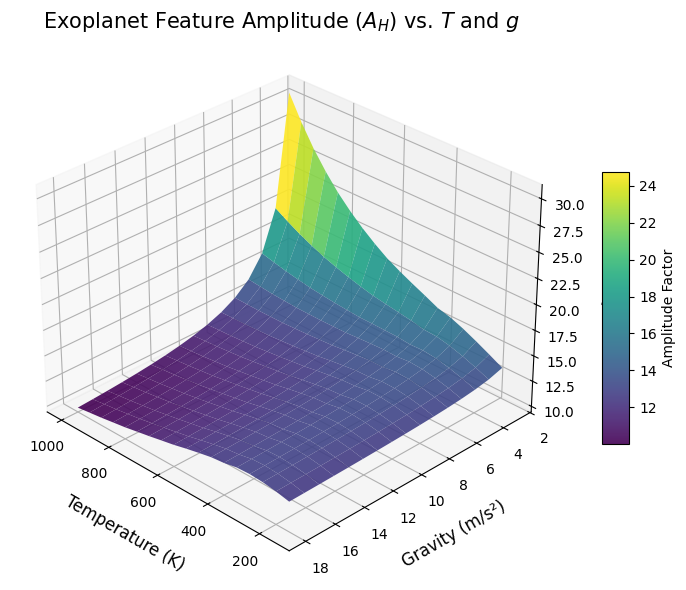

In [2]:
from mpl_toolkits.mplot3d import Axes3D

# 1. Convert your results to numpy arrays
# all_temp is a list of scalars (one per outer loop)
# all_gravity[0] gives us the unique gravity values used in the inner loop
# all_A_H is a list of lists (the 2D result grid)
T_axis = np.array(all_temp)
G_axis = np.array(all_gravity[0])
Z = np.array(all_A_H)

# 2. Handle any NaNs that might break the plot
Z = np.nan_to_num(Z, nan=0.0)

# 3. Create the 2D grid for the X and Y coordinates
# This creates a coordinate for every (Temp, Gravity) pair
G_grid, T_grid = np.meshgrid(G_axis, T_axis)

# 4. Initialize the 3D Plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# 5. Plot the Surface
# cmap='magma' or 'viridis' helps visualize height changes
surf = ax.plot_surface(T_grid, G_grid, Z, cmap='viridis', 
                       edgecolor='none', alpha=0.9, antialiased=True)

# 6. Add Labels and Formatting
ax.set_xlabel('Temperature (K)', fontsize=12, labelpad=10)
ax.set_ylabel('Gravity (m/s²)', fontsize=12, labelpad=10)
ax.set_zlabel(r'$A_H$', fontsize=14, labelpad=10)
ax.set_title('Exoplanet Feature Amplitude ($A_H$) vs. $T$ and $g$', fontsize=15)
# Add a color bar for better scale reading
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Amplitude Factor')

# Adjust the viewing angle for best visibility
ax.view_init(elev=30, azim=135)

plt.tight_layout()
plt.show()

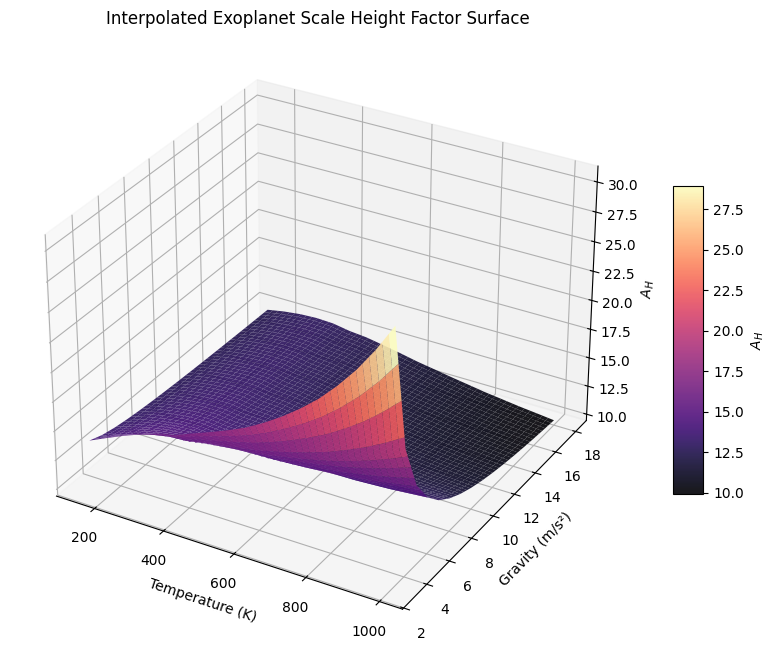

In [4]:
from scipy.interpolate import RegularGridInterpolator

# 1. Define your existing axes and data
T_axis = np.array(all_temp)
G_axis = np.array(all_gravity[0])
Z = np.array(all_A_H)

# 2. Create the Interpolator function
# Note: RegularGridInterpolator expects the grid axes as a tuple
interp_func = RegularGridInterpolator((T_axis, G_axis), Z, method='linear', bounds_error=False, fill_value=None)

# 3. Create a much finer grid (e.g., 100x100 points)
T_fine = np.linspace(T_axis.min(), T_axis.max(), 1000)
G_fine = np.linspace(G_axis.min(), G_axis.max(), 1000)
T_mesh_fine, G_mesh_fine = np.meshgrid(T_fine, G_fine, indexing='ij')

# 4. Apply the interpolation to the fine grid
# Flatten the grids to pass through the interpolator, then reshape back to 2D
points = np.array([T_mesh_fine.flatten(), G_mesh_fine.flatten()]).T
Z_fine = interp_func(points).reshape(1000, 1000)

# 5. Plot the smooth surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Using 'antialiased=True' and a high-res grid makes the plot look professional
surf = ax.plot_surface(T_mesh_fine, G_mesh_fine, Z_fine, cmap='magma', 
                       edgecolor='none', alpha=0.9, antialiased=True)

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Gravity (m/s²)')
ax.set_zlabel(r'$A_H$')
ax.set_title('Interpolated Exoplanet Scale Height Factor Surface')

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='$A_H$')
plt.show()

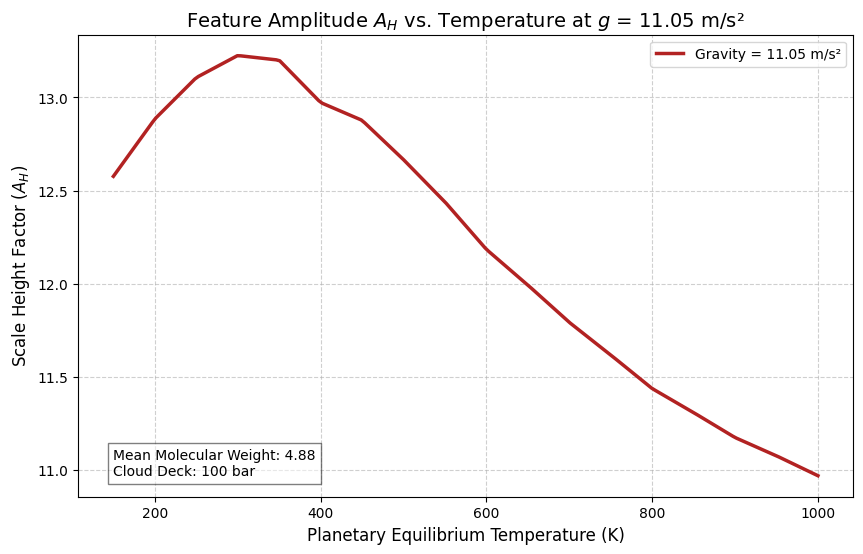

In [5]:
# 1. Define the specific gravity you want to investigate
target_g = 11.05

# 2. Create a range of temperatures for the X-axis
# Using the min/max from your actual data
temp_range = np.linspace(min(all_temp), max(all_temp), 200)

# 3. Use the interpolator to get A_H values at g = 11.05
# We create pairs of (temp, 11.05) for every temperature in our range
query_points = np.array([[t, target_g] for t in temp_range])
A_H_at_target_g = interp_func(query_points)

# 4. Create the 2D Plot
plt.figure(figsize=(10, 6))
plt.plot(temp_range, A_H_at_target_g, color='firebrick', lw=2.5, label=f'Gravity = {target_g} m/s²')

# 5. Formatting
plt.title(f'Feature Amplitude $A_H$ vs. Temperature at $g$ = {target_g} m/s²', fontsize=14)
plt.xlabel('Planetary Equilibrium Temperature (K)', fontsize=12)
plt.ylabel(r'Scale Height Factor ($A_H$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Optional: Add a text box with model assumptions
plt.text(temp_range.min(), min(A_H_at_target_g), 
         f"Mean Molecular Weight: {mu:.2f}\nCloud Deck: 100 bar", 
         bbox=dict(facecolor='white', alpha=0.5))

plt.show()

In [6]:
interp_func([300,11.05])

array([13.22546067])

In [31]:
with open("/Users/sahil/Group-Studies---Exoplanets/Code/Data/All_165_valid_planets_under_1000K05.02_16-10.csv", newline="") as PlanetaryParametersFile:   
	reader = csv.reader(PlanetaryParametersFile)
	header = next(reader)
	data = []
	planetnames = []
	for row in reader:
		row = [item.strip() for item in row]
		if len(row) == 0:
			continue
		name, *nums = row
		conv = [float(item) if item != "" else np.nan for item in nums]
		data.append(conv)
		planetnames.append(name)
	planetary_03 = np.array(data, dtype=float)



index = 0
model_AH = []
model_temp = []
actual_AH = []


while index < len(planetary_03):
    Rp = planetary_03[index][3] * const.R_earth.value     ## planet radius in units of Earth radii * Earth radius in m
    Mp = planetary_03[index][2]                           ## planet mass in units of Earth masses
    Tp = planetary_03[index][39]                          ## planet temperature in K
    Rs = planetary_03[index][14] * const.R_sun.value      ## stellar radius in units of Solar radii * Solar radius in m    
    mu = 4.88 * sc.u                                       		   ## mean molecular weight in atomic mass units * atomic mass unit in kg
    Pcloud = 100 * 1.0e5                                   		   ## pressure at top of cloud deck in Pa (100 bar) * convert to Pa
    Pref = 0.01 * 1.0e5 
    
    P = np.logspace(2.0,-9,100) * 1.0e5
    T = Tp * np.ones_like(P)
    n = P/(sc.k * T)
    rho = mu*n
    gp = planetary_03[index][37] * 0.01

    r = np.zeros_like(P)
    g = np.zeros_like(P)

    i_Rp = np.argmin(np.abs(P-Pref))
    r[i_Rp] = Rp
    g[i_Rp] = gp

    # First, set up a dictionary which will contain all the log mixing ratios, and input the abundances of all molecules except H2 and He
    logX = dict()
    logX['h2o'] = -1.1
    logX['ch4'] = -1.74
    logX['co'] = -2.0
    logX['co2'] = -1.7
    #logX['nh3'] = -3.0

    ## We'll also need to know the mean molecular weights of each molecule (here in units of amu) ##
    mmw = dict()
    mmw['h2o'] = 18.0
    mmw['ch4'] = 16.0
    mmw['co'] = 28.0
    mmw['co2'] = 44.0
    mmw['h2'] = 2.0
    mmw['he'] = 4.0
    
    # Now we can 'fill' the rest of the atmosphere with H2 and He, which are typically the most abudnant background gases.
    # Let's assume that the ratio of H2 to He is the same as that in the Sun, i.e. X_He/X_H2 = 0.17 (Asplund et al. 2009 shows that X_He/X_H = 0.085, and going from H to H2 means doubling that)
    # Then X_H2 + X_He = 1 - X_rest

    X_rest = np.sum([np.power(10.0,logX[key]) for key in logX.keys()])
    X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
    X_He = 0.17 * X_H2

    # Now let's add H2 and He to the logX dictionary

    logX['h2'] = np.log10(X_H2)
    logX['he'] = np.log10(X_He)

    for i in range(i_Rp + 1, len(P)):
        g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i-1] * r[i-1])
        r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 

    for i in range(i_Rp-1, -1, -1):
        g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i+1] * r[i+1])
        r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])

    # With all the mixing ratios defined, we can calculate the mean molecular weight of the atmosphere, mu:
    mu = 0.0
    for mol in logX.keys():
        mu += np.power(10.0,logX[mol])*mmw[mol]

    xsec_dict = dict()
    lam_dict = dict()
    P_dict = dict()
    T_dict = dict()
    

    lam = np.linspace(0.61,5.0,500)

    log_xsec_dict = dict()

    lamlam, PP = np.meshgrid(lam, P, indexing="ij")

    # ---- H2O ----
    interp_h2o = RegularGridInterpolator(
        (lam_h2o, P_h2o, T_h2o),
        xsec_h2o,
        method='linear', bounds_error=False,
        fill_value=None)
    log_xsec_dict['h2o'] = interp_h2o((lamlam, PP, T[0]))

    # ---- CO2 ----
    interp_co2 = RegularGridInterpolator(
        (lam_co2, P_co2, T_co2),
        xsec_co2,
        method='linear', bounds_error=False,
        fill_value=None
    )
    log_xsec_dict['co2'] = interp_co2((lamlam, PP, T[0]))

    # ---- CH4 ----
    interp_ch4 = RegularGridInterpolator(
        (lam_ch4, P_ch4, T_ch4),
        xsec_ch4,
        method='linear', bounds_error=False,
        fill_value=None
    )
    log_xsec_dict['ch4'] = interp_ch4((lamlam, PP, T[0]))

    interp_co2 = RegularGridInterpolator(
        (lam_co, P_co, T_co),
        xsec_co,
        method='linear', bounds_error=False,
        fill_value=None
    )
    log_xsec_dict['co'] = interp_co2((lamlam, PP, T[0]))

    log_cia_dict = dict()
    log_cia_dict['h2h2'] = np.interp(lam, lam_h2h2, xsec_h2h2)
    log_cia_dict['heh2'] = np.interp(lam, lam_heh2, xsec_heh2)

    sum_nsigma = np.zeros((len(lam), len(P)))
    for mol in log_xsec_dict.keys():
        sum_nsigma += n[np.newaxis,:]*np.power(10.0,logX[mol])*np.power(10.0,log_xsec_dict[mol])

    sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['h2'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['h2h2'])[:,np.newaxis]
    sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['he'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['heh2'])[:,np.newaxis]

    integral_gt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r>Rp" integral
    integral_lt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r<Rp" integral

    exptau = np.zeros((len(P),len(lam)))
    transit_depth = np.zeros((len(lam)))

    # Compute the total optical depth at each impact parameter and wavelength #

    opacity = sum_nsigma #(kappa+sigma)
    # For each layer of atmosphere

    for i in range(len(r)-1):

        s_tot = np.sqrt(r[i:]*r[i:]-r[i]*r[i])
        ds = s_tot[1:]-s_tot[:-1]

        tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:],axis=-1)

        # If r[i] is deeper that the top of the cloud, the atmosphere here is fully opaque and tau is very large.
        if P[i] > Pcloud:
            tau_tot += 1000.0

        # We need e^(-tau) for the integral, so let's calculate that here. Adding 1.0-e-250 avoids errors when taking the log of this in cases where e^-tau is essentially zero.
        exptau[i, :] = np.exp(-1.0*tau_tot) + 1.0e-250


    # Compute transit depth terms. Note that we take an average of the i^th and (i+1)^th terms in the integrals.
    for i in range(len(r)-1):

        # Rays travelling through atmosphere above Rp
        if (r[i] >= Rp):
            integral_gt_Rp[:] += 0.5*((r[i]*(1.0 - exptau[i, :]) + (r[i+1]*(1.0 - exptau[i+1, :])))*(r[i+1] - r[i]))

        # Rays travelling through atmosphere below Rp
        if (r[i] < Rp):
            integral_lt_Rp[:] += 0.5*((r[i]*(exptau[i, :]) + (r[i+1]*(exptau[i+1, :])))*(r[i+1] - r[i]))

    # Compute effective transit depth (transmission spectrum) #
    transit_depth[:] = (Rp*Rp + 2.0*integral_gt_Rp[:] - 2.0*integral_lt_Rp[:])/(Rs*Rs)


    lam_data = lam
    depth_data = transit_depth

    left_mask = (lam_data >= 4.1) & (lam_data <= 4.15)   # CO2 feature
	
    left_depth_values = depth_data[left_mask]
    left_lam_values = lam_data[left_mask]
	
    left_val = np.mean(left_depth_values)
    left_lam_target = np.mean(left_lam_values)
    peak_mask = (lam_data >= 4.25) & (lam_data <= 4.28)   # CO2 feature
	# Extract values in that window
    peak_region_depths = depth_data[peak_mask]
    peak_x_values = lam_data[peak_mask]

	# 5. Calculate Height and the Scatter Error
    peak_val = np.mean(peak_region_depths)
    peak_x_value = np.mean(peak_x_values)
    feature_height_ratio = (peak_val - left_val)
    feature_height_ppm = (peak_val - left_val) * 1e6

    scale_height = (sc.k * Tp) / (mu * gp * sc.m_p)


    A_H = feature_height_ratio * (Rs ** 2) / (2 * scale_height * Rp)
    actual_AH.append(A_H)
    print(f'Planet {planetnames[index]}, with A_H = {A_H}')
    
    index += 1




Planet EPIC 220674823 c, with A_H = 12.154473080704122
Planet G 9-40 b, with A_H = 13.375031676610398
Planet GJ 1214 b, with A_H = 12.553768310900546
Planet GJ 3090 b, with A_H = 14.016586799842779
Planet GJ 9827 d, with A_H = 14.101698287096614
Planet HD 135694 b, with A_H = 12.779684824516783
Planet HD 15337 b, with A_H = 10.881390497048333
Planet HD 15337 c, with A_H = 12.400497282247587
Planet HD 191939 c, with A_H = 12.781085954352296
Planet HD 191939 d, with A_H = 16.79109740699501
Planet HD 23472 b, with A_H = 12.218741731286254
Planet HD 23472 c, with A_H = 13.657734600937559
Planet HD 235088 b, with A_H = 12.828174320326005
Planet HD 28109 b, with A_H = 12.377353842353918
Planet HD 42813 b, with A_H = 12.178536752870903
Planet HD 73583 c, with A_H = 12.530218390004919
Planet HIP 116454 b, with A_H = 11.463616412021265
Planet HIP 29442 d, with A_H = 11.145418230012178
Planet HIP 8152 b, with A_H = 11.277850669805485
Planet K2-138 d, with A_H = 11.15178654225742
Planet K2-138 f,

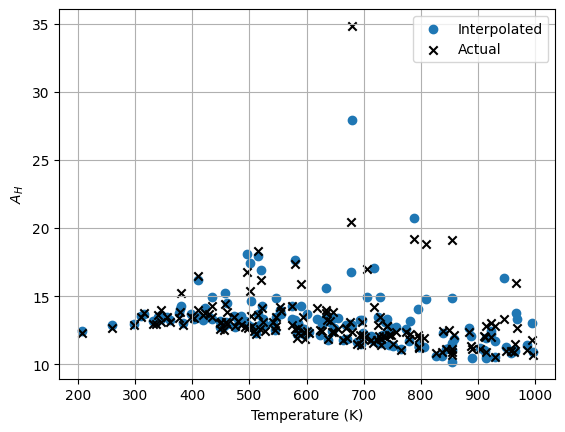

In [ ]:
loaded_data = np.load("/Users/sahil/Group-Studies---Exoplanets/Group 1 Full Loop Code/exoplanetTg_data.npy")
loaded_data2 = np.load("/Users/sahil/Group-Studies---Exoplanets/Group 1 Full Loop Code/exoplanetAH_data.npy")
T_axis = loaded_data[:, 0] # Extract the temperature values
G_axis = loaded_data[:, 1]     # Extract the gravity values           
Z = loaded_data2               # Extract the A_H values

interp_func01 = RegularGridInterpolator((T_axis, G_axis), Z, method='linear', bounds_error=False, fill_value=None)

model_AH = []
model_temp = []
i = 0
while i < len(planetary_03):
    gravity_p = planetary_03[i][37] * 0.01
    temp_p = planetary_03[i][39]
    interpolated_AH = interp_func01([temp_p,gravity_p])
    model_AH.append(interpolated_AH)
    model_temp.append(temp_p)

    i += 1


plt.scatter(model_temp,model_AH, label = 'Interpolated')
plt.scatter(model_temp, actual_AH, label = 'Actual', marker = 'x', color = 'black')
plt.ylabel('$A_H$')
plt.xlabel('Temperature (K)')
plt.grid(True)
plt.legend()


Text(0.5, 1.0, 'Interpolated $A_H$ / Calculated $A_H$ ')

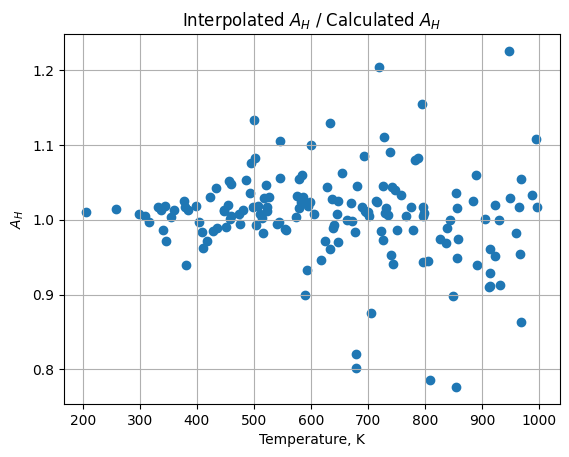

In [35]:
index2 = 0
ratios_AH = []
while index2 < len(model_AH):
    ratio_AH = model_AH[index2] / actual_AH[index2]
    ratios_AH.append(ratio_AH)
    index2 += 1


plt.scatter(model_temp, ratios_AH)
plt.ylabel('$A_H$')
plt.xlabel('Temperature, K')
plt.grid(True)
plt.title('Interpolated $A_H$ / Calculated $A_H$ ')

Text(0.5, 1.0, 'Interpolated $A_H$ VS Calculated $A_H$ ')

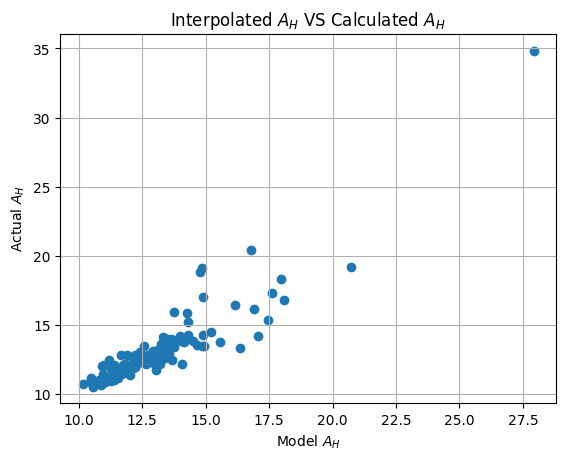

In [36]:
plt.scatter(model_AH, actual_AH,)
plt.ylabel('Actual $A_H$')
plt.xlabel('Model $A_H$')
plt.grid(True)
plt.title('Interpolated $A_H$ VS Calculated $A_H$ ')

In [1]:
import scipy.constants as sc
from scipy.interpolate import RegularGridInterpolator
import astropy.constants as const
import matplotlib.pyplot as plt
import csv
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

xsec_h2o = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_xsec.npy')
lam_h2o = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_lam.npy')*1e6 # convert to microns
P_h2o = np.power(10.0,np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_P.npy')) # already in Pa
T_h2o = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_T.npy')
interp_h2o = RegularGridInterpolator(
        (lam_h2o, P_h2o, T_h2o),
        xsec_h2o,
        method='linear', bounds_error=False,
        fill_value=None)

# Read in CO2 cross section data
xsec_co2 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_xsec.npy')
lam_co2 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_lam.npy')*1e6 # convert to microns
P_co2 = np.power(10.0,np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_P.npy')) # already in Pa
T_co2 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_T.npy')
interp_co2 = RegularGridInterpolator(
        (lam_co2, P_co2, T_co2),
        xsec_co2,
        method='linear', bounds_error=False,
        fill_value=None)

# Read in CH4 cross section data
xsec_ch4 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_xsec.npy')
lam_ch4 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_lam.npy')*1e6 # convert to microns
P_ch4 = np.power(10.0,np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_P.npy')) # already in Pa
T_ch4 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_T.npy')
interp_ch4 = RegularGridInterpolator(
        (lam_ch4, P_ch4, T_ch4),
        xsec_ch4,
        method='linear', bounds_error=False,
        fill_value=None)

#read in CO cross section data
xsec_co = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_xsec.npy')
lam_co = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_lam.npy')*1e6 # convert to microns   
P_co = np.power(10.0,np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_P.npy')) # already in Pa
T_co = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_T.npy')
interp_co2 = RegularGridInterpolator(
        (lam_co, P_co, T_co),
        xsec_co,
        method='linear', bounds_error=False,
        fill_value=None)

# H2-H2 and He-H2 molecule pairs cause absorption through a process called "collision-induced absorption". This data is wavelength- and temperature-dependent, but not pressure-dependent.
xsec_h2h2 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_xsec.npy')
lam_h2h2 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_lam.npy')

xsec_heh2 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_xsec.npy')
lam_heh2 = np.load('/Users/sahil/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_lam.npy')



In [4]:
temperaturelist = np.linspace(150, 1000, 100)
gravitylinspace = np.linspace(300, 2000, 100)


all_gravity = []
all_A_H = []
all_temp = []

for temperature in temperaturelist:
    gravitylist = []
    A_H_Array = []
    temparray = []

    for gravity in gravitylinspace:

        Rp = 2.733 * const.R_earth.value     ## planet radius in units of Earth radii * Earth radius in m
        Mp = 8.41                          ## planet mass in units of Earth masses
        Tp = temperature                          ## planet temperature in K
        Rs = 0.2162 * const.R_sun.value      ## stellar radius in units of Solar radii * Solar radius in m    
        mu = 4.88 * sc.u                                       		   ## mean molecular weight in atomic mass units * atomic mass unit in kg
        Pcloud = 100 * 1.0e5                                   		   ## pressure at top of cloud deck in Pa (100 bar) * convert to Pa
        Pref = 0.01 * 1.0e5 
        
        P = np.logspace(2.0,-9,100) * 1.0e5
        T = Tp * np.ones_like(P)
        n = P/(sc.k * T)
        rho = mu*n
        gp = gravity * 0.01
        gravitylist.append(gp)

        r = np.zeros_like(P)
        g = np.zeros_like(P)

        i_Rp = np.argmin(np.abs(P-Pref))
        r[i_Rp] = Rp
        g[i_Rp] = gp

        # First, set up a dictionary which will contain all the log mixing ratios, and input the abundances of all molecules except H2 and He
        logX = dict()
        logX['h2o'] = -1.1
        logX['ch4'] = -1.74
        logX['co'] = -2.0
        logX['co2'] = -1.7
        #logX['nh3'] = -3.0

        ## We'll also need to know the mean molecular weights of each molecule (here in units of amu) ##
        mmw = dict()
        mmw['h2o'] = 18.0
        mmw['ch4'] = 16.0
        mmw['co'] = 28.0
        mmw['co2'] = 44.0
        mmw['h2'] = 2.0
        mmw['he'] = 4.0
        
        # Now we can 'fill' the rest of the atmosphere with H2 and He, which are typically the most abudnant background gases.
        # Let's assume that the ratio of H2 to He is the same as that in the Sun, i.e. X_He/X_H2 = 0.17 (Asplund et al. 2009 shows that X_He/X_H = 0.085, and going from H to H2 means doubling that)
        # Then X_H2 + X_He = 1 - X_rest

        X_rest = np.sum([np.power(10.0,logX[key]) for key in logX.keys()])
        X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
        X_He = 0.17 * X_H2

        # Now let's add H2 and He to the logX dictionary

        logX['h2'] = np.log10(X_H2)
        logX['he'] = np.log10(X_He)

        for i in range(i_Rp + 1, len(P)):
            g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i-1] * r[i-1])
            r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 

        for i in range(i_Rp-1, -1, -1):
            g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i+1] * r[i+1])
            r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])

        # With all the mixing ratios defined, we can calculate the mean molecular weight of the atmosphere, mu:
        mu = 0.0
        for mol in logX.keys():
            mu += np.power(10.0,logX[mol])*mmw[mol]

        xsec_dict = dict()
        lam_dict = dict()
        P_dict = dict()
        T_dict = dict()
        

        lam = np.linspace(0.61,5.0,5000)

        log_xsec_dict = dict()

        lamlam, PP = np.meshgrid(lam, P, indexing="ij")

        interp_h2o = RegularGridInterpolator(
			(lam_h2o, P_h2o, T_h2o),
			xsec_h2o,
			method='linear', bounds_error=False,
			fill_value=None)
        log_xsec_dict['h2o'] = interp_h2o((lamlam, PP, T[0]))

		# ---- CO2 ----
        interp_co2 = RegularGridInterpolator(
			(lam_co2, P_co2, T_co2),
			xsec_co2,
			method='linear', bounds_error=False,
			fill_value=None
		)
        log_xsec_dict['co2'] = interp_co2((lamlam, PP, T[0]))

		# ---- CH4 ----
        interp_ch4 = RegularGridInterpolator(
			(lam_ch4, P_ch4, T_ch4),
			xsec_ch4,
			method='linear', bounds_error=False,
			fill_value=None
		)
        log_xsec_dict['ch4'] = interp_ch4((lamlam, PP, T[0]))

        interp_co2 = RegularGridInterpolator(
			(lam_co, P_co, T_co),
			xsec_co,
			method='linear', bounds_error=False,
			fill_value=None
		)

        log_cia_dict = dict()
        log_cia_dict['h2h2'] = np.interp(lam, lam_h2h2, xsec_h2h2)
        log_cia_dict['heh2'] = np.interp(lam, lam_heh2, xsec_heh2)

        sum_nsigma = np.zeros((len(lam), len(P)))
        for mol in log_xsec_dict.keys():
            sum_nsigma += n[np.newaxis,:]*np.power(10.0,logX[mol])*np.power(10.0,log_xsec_dict[mol])

        sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['h2'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['h2h2'])[:,np.newaxis]
        sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['he'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['heh2'])[:,np.newaxis]

        integral_gt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r>Rp" integral
        integral_lt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r<Rp" integral

        exptau = np.zeros((len(P),len(lam)))
        transit_depth = np.zeros((len(lam)))

        # Compute the total optical depth at each impact parameter and wavelength #

        opacity = sum_nsigma #(kappa+sigma)
        # For each layer of atmosphere

        for i in range(len(r)-1):

            s_tot = np.sqrt(r[i:]*r[i:]-r[i]*r[i])
            ds = s_tot[1:]-s_tot[:-1]

            tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:],axis=-1)

            # If r[i] is deeper that the top of the cloud, the atmosphere here is fully opaque and tau is very large.
            if P[i] > Pcloud:
                tau_tot += 1000.0

            # We need e^(-tau) for the integral, so let's calculate that here. Adding 1.0-e-250 avoids errors when taking the log of this in cases where e^-tau is essentially zero.
            exptau[i, :] = np.exp(-1.0*tau_tot) + 1.0e-250


        # Compute transit depth terms. Note that we take an average of the i^th and (i+1)^th terms in the integrals.
        for i in range(len(r)-1):

            # Rays travelling through atmosphere above Rp
            if (r[i] >= Rp):
                integral_gt_Rp[:] += 0.5*((r[i]*(1.0 - exptau[i, :]) + (r[i+1]*(1.0 - exptau[i+1, :])))*(r[i+1] - r[i]))

            # Rays travelling through atmosphere below Rp
            if (r[i] < Rp):
                integral_lt_Rp[:] += 0.5*((r[i]*(exptau[i, :]) + (r[i+1]*(exptau[i+1, :])))*(r[i+1] - r[i]))

        # Compute effective transit depth (transmission spectrum) #
        transit_depth[:] = (Rp*Rp + 2.0*integral_gt_Rp[:] - 2.0*integral_lt_Rp[:])/(Rs*Rs)


        lam_data = lam
        depth_data = transit_depth

        left_mask = (lam_data >= 4.1) & (lam_data <= 4.15)   # CO2 feature

        left_depth_values = depth_data[left_mask]
        left_lam_values = lam_data[left_mask]
        
        left_val = np.mean(left_depth_values)
        left_lam_target = np.mean(left_lam_values)
        peak_mask = (lam_data >= 4.25) & (lam_data <= 4.28)   # CO2 feature
        # Extract values in that window
        peak_region_depths = depth_data[peak_mask]
        peak_x_values = lam_data[peak_mask]

        # 5. Calculate Height and the Scatter Error
        peak_val = np.mean(peak_region_depths)
        peak_x_value = np.mean(peak_x_values)
        feature_height_ratio = (peak_val - left_val)
        feature_height_ppm = (peak_val - left_val) * 1e6


        # The "Error" is the standard deviation of the points in the peak region
        # This represents the local variation/noise in your model
        peak_scatter_error_ppm = np.std(peak_region_depths) * 1e6

        scale_height = (sc.k * Tp) / (mu * gp * sc.m_p)

        A_H = feature_height_ratio * (Rs ** 2) / (2 * scale_height * Rp)
        A_H_Array.append(A_H)


    all_gravity.append(gravitylist)
    all_A_H.append(A_H_Array)
    all_temp.append(Tp)

data = {
    'A_H': all_A_H,
    'Gravity': all_gravity,
    'Temperature': all_temp}

df = pd.DataFrame(data)
df.to_csv("/Users/sahil/Group-Studies---Exoplanets/Notebooks/test plots/testAHdata.txt", index=False, sep=",")

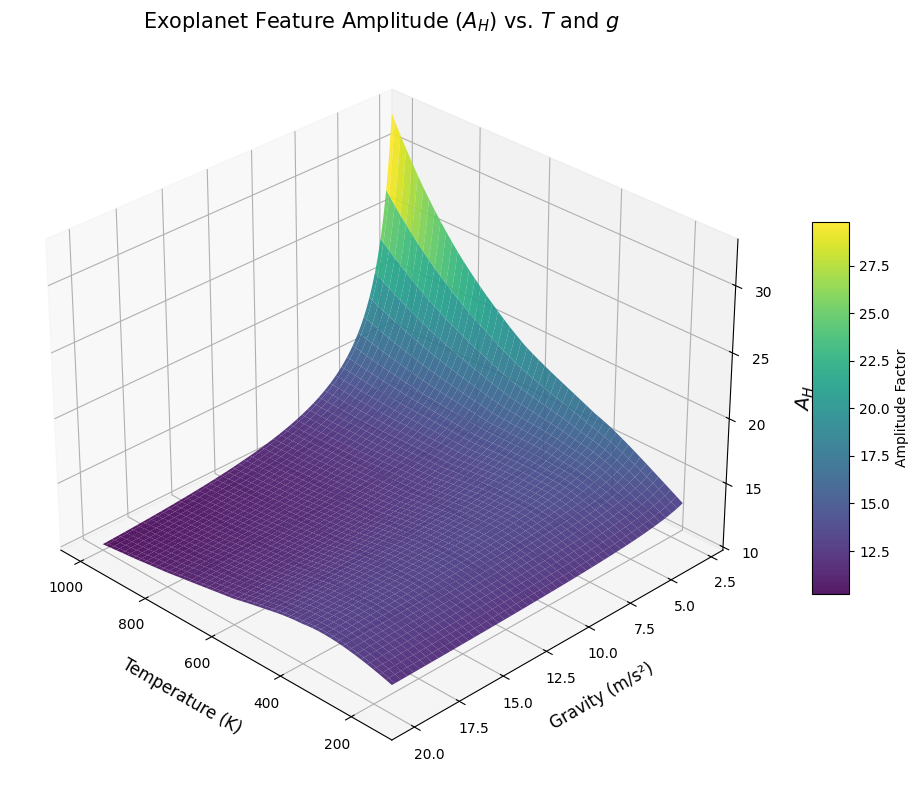

In [29]:
from mpl_toolkits.mplot3d import Axes3D

T_axis = np.array(all_temp) # Extract the temperature values
G_axis = np.array(all_gravity[0])     # Extract the gravity values
Z = np.array(all_A_H)             # Extract the A_H values

data_to_save = np.column_stack((T_axis, G_axis))
# Save as .npy
np.save("/Users/sahil/Group-Studies---Exoplanets/Notebooks/test plots/exoplanetTg_data.npy", data_to_save)
np.save("/Users/sahil/Group-Studies---Exoplanets/Notebooks/test plots/exoplanetAH_data.npy", Z)


interp_func = RegularGridInterpolator((T_axis, G_axis), Z, method='linear', bounds_error=False, fill_value=None)
# 2. Handle any NaNs that might break the plot
Z = np.nan_to_num(Z, nan=0.0)

# 3. Create the 2D grid for the X and Y coordinates
# This creates a coordinate for every (Temp, Gravity) pair
G_grid, T_grid = np.meshgrid(G_axis, T_axis)

# 4. Initialize the 3D Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 5. Plot the Surface
# cmap='magma' or 'viridis' helps visualize height changes
surf = ax.plot_surface(T_grid, G_grid, Z, cmap='viridis', 
                       edgecolor='none', alpha=0.9, antialiased=True)

# 6. Add Labels and Formatting
ax.set_xlabel('Temperature (K)', fontsize=12, labelpad=10)
ax.set_ylabel('Gravity (m/s²)', fontsize=12, labelpad=10)
ax.set_zlabel(r'$A_H$', fontsize=14, labelpad=10)
ax.set_title('Exoplanet Feature Amplitude ($A_H$) vs. $T$ and $g$', fontsize=15)
# Add a color bar for better scale reading
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Amplitude Factor')

# Adjust the viewing angle for best visibility
ax.view_init(elev=30, azim=135)

plt.tight_layout()
plt.show()

In [ ]:
interp_func([300,11.05])       

array([13.28586213])

In [ ]:
loaded_data = np.load("/Users/sahil/Group-Studies---Exoplanets/Notebooks/test plots/exoplanet_data.npy")
loaded_data2 = np.load("/Users/sahil/Group-Studies---Exoplanets/Notebooks/test plots/exoplanetAH_data.npy")
T_axis = loaded_data[:, 0]     # Extract the temperature values
G_axis = loaded_data[:, 1]     # Extract the gravity values           
Z = loaded_data2               # Extract the A_H values

interp_func = RegularGridInterpolator((T_axis, G_axis), Z, method='linear', bounds_error=False, fill_value=None)

interp_func([300,11.05])

array([13.28586213])